In [1]:
!pip install -q langchain langchain-core langchain-community langgraph langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
from google.colab import userdata
import os

os.environ["GROQ_API_KEY"] = userdata.get("groq")

In [3]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [4]:
from typing_extensions import TypedDict

class State(TypedDict):
    application: str
    experience_level: str
    skill_match: str
    response: str

In [5]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(State)

In [6]:
from langchain_core.prompts import ChatPromptTemplate

In [7]:
def categorize_experience(state: State):

    print("\nCategorizing candidate experience...")

    prompt = ChatPromptTemplate.from_template(
        """
        Based on the following job application,
        categorize the candidate as ONLY one of:

        Entry-level
        Mid-level
        Senior-level

        Application:
        {application}
        """
    )

    chain = prompt | llm

    experience_level = chain.invoke(
        {"application": state["application"]}
    ).content.strip()

    print("Experience Level:", experience_level)

    return {
        "experience_level": experience_level
    }

In [8]:
def assess_skillset(state: State):

    print("\nAssessing candidate skills...")

    prompt = ChatPromptTemplate.from_template(
        """
        Job Role: Python Developer

        Check whether the candidate is suitable.

        Respond ONLY with:

        Match

        OR

        No Match

        Application:
        {application}
        """
    )

    chain = prompt | llm

    skill_match = chain.invoke(
        {"application": state["application"]}
    ).content.strip()

    print("Skill Match:", skill_match)

    return {
        "skill_match": skill_match
    }

In [9]:
def schedule_hr_interview(state: State):

    print("\nScheduling HR Interview")

    return {
        "response": "Candidate shortlisted for HR interview."
    }


def escalate_to_recruiter(state: State):

    print("\nEscalating to Recruiter")

    return {
        "response": "Senior candidate but skills do not match. Recruiter review required."
    }


def reject_application(state: State):

    print("\nRejecting Candidate")

    return {
        "response": "Candidate rejected."
    }

In [10]:
workflow.add_node(
    "categorize_experience",
    categorize_experience
)

workflow.add_node(
    "assess_skillset",
    assess_skillset
)

workflow.add_node(
    "schedule_hr_interview",
    schedule_hr_interview
)

workflow.add_node(
    "escalate_to_recruiter",
    escalate_to_recruiter
)

workflow.add_node(
    "reject_application",
    reject_application
)

In [11]:
def route_app(state: State):

    if state["skill_match"] == "Match":
        return "schedule_hr_interview"

    elif state["experience_level"] == "Senior-level":
        return "escalate_to_recruiter"

    else:
        return "reject_application"

In [12]:
workflow.add_edge(
    START,
    "categorize_experience"
)

workflow.add_edge(
    "categorize_experience",
    "assess_skillset"
)

workflow.add_conditional_edges(
    "assess_skillset",
    route_app,
    {
        "schedule_hr_interview": "schedule_hr_interview",
        "escalate_to_recruiter": "escalate_to_recruiter",
        "reject_application": "reject_application"
    }
)

workflow.add_edge(
    "schedule_hr_interview",
    END
)

workflow.add_edge(
    "escalate_to_recruiter",
    END
)

workflow.add_edge(
    "reject_application",
    END
)

In [13]:
app = workflow.compile()

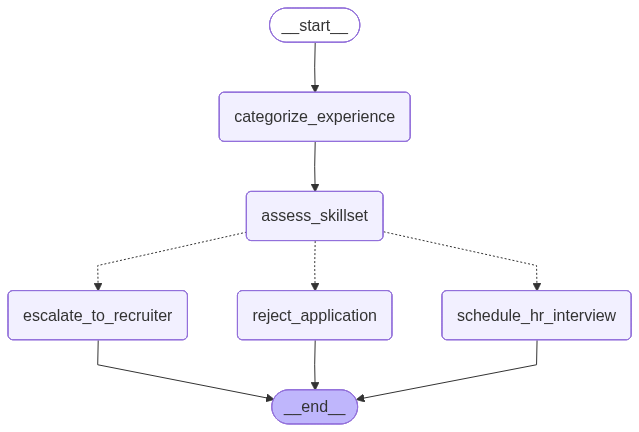

In [14]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [15]:
def run_candidate_screening(application: str):

    results = app.invoke(
        {"application": application}
    )

    return {
        "experience_level": results["experience_level"],
        "skill_match": results["skill_match"],
        "response": results["response"]
    }

In [16]:
application_text = """
I have 10 years of experience in software engineering with expertise in JAVA
"""

results = run_candidate_screening(application_text)

print("\nComputed Results:")
print("Application:", application_text)
print("Experience Level:", results["experience_level"])
print("Skill Match:", results["skill_match"])
print("Response:", results["response"])


Categorizing candidate experience...
Experience Level: Based on the job application, I would categorize the candidate as:

Senior-level

The candidate has 10 years of experience in software engineering, which suggests a high level of expertise and maturity in their field, typical of a senior-level professional.

Assessing candidate skills...
Skill Match: No Match

Rejecting Candidate

Computed Results:
Application: 
I have 10 years of experience in software engineering with expertise in JAVA

Experience Level: Based on the job application, I would categorize the candidate as:

Senior-level

The candidate has 10 years of experience in software engineering, which suggests a high level of expertise and maturity in their field, typical of a senior-level professional.
Skill Match: No Match
Response: Candidate rejected.


In [17]:
application_text = """
I have 1 year of experience in software engineering with expertise in JAVA
"""

results = run_candidate_screening(application_text)

print("\nComputed Results:")
print("Application:", application_text)
print("Experience Level:", results["experience_level"])
print("Skill Match:", results["skill_match"])
print("Response:", results["response"])


Categorizing candidate experience...
Experience Level: Based on the job application, I would categorize the candidate as:

Entry-level

Reason: The candidate has only 1 year of experience in software engineering, which is typically considered entry-level.

Assessing candidate skills...
Skill Match: No Match

Rejecting Candidate

Computed Results:
Application: 
I have 1 year of experience in software engineering with expertise in JAVA

Experience Level: Based on the job application, I would categorize the candidate as:

Entry-level

Reason: The candidate has only 1 year of experience in software engineering, which is typically considered entry-level.
Skill Match: No Match
Response: Candidate rejected.


In [18]:
application_text = """
I have experience in software engineering with expertise in Python
"""

results = run_candidate_screening(application_text)

print("\nComputed Results:")
print("Application:", application_text)
print("Experience Level:", results["experience_level"])
print("Skill Match:", results["skill_match"])
print("Response:", results["response"])


Categorizing candidate experience...
Experience Level: Based on the provided information, I would categorize the candidate as:

Entry-level

The reason for this categorization is that the candidate mentions having "experience" but does not provide any specific details about the duration, depth, or scope of their experience. Additionally, they only mention a general expertise in Python, without highlighting any advanced skills, leadership roles, or significant achievements that would suggest a higher level of experience.

Assessing candidate skills...
Skill Match: Match

Scheduling HR Interview

Computed Results:
Application: 
I have experience in software engineering with expertise in Python

Experience Level: Based on the provided information, I would categorize the candidate as:

Entry-level

The reason for this categorization is that the candidate mentions having "experience" but does not provide any specific details about the duration, depth, or scope of their experience. Addition

In [19]:
application_text = """
I have 5 years of experience in software engineering with expertise in C++
"""

results = run_candidate_screening(application_text)

print("\nComputed Results:")
print("Application:", application_text)
print("Experience Level:", results["experience_level"])
print("Skill Match:", results["skill_match"])
print("Response:", results["response"])


Categorizing candidate experience...
Experience Level: Based on the job application, I would categorize the candidate as:

Mid-level

Reason: 5 years of experience is typically considered mid-level, as it indicates the candidate has gained significant experience and expertise in their field, but may not yet have the extensive experience and leadership responsibilities typically associated with senior-level positions.

Assessing candidate skills...
Skill Match: No Match

Rejecting Candidate

Computed Results:
Application: 
I have 5 years of experience in software engineering with expertise in C++

Experience Level: Based on the job application, I would categorize the candidate as:

Mid-level

Reason: 5 years of experience is typically considered mid-level, as it indicates the candidate has gained significant experience and expertise in their field, but may not yet have the extensive experience and leadership responsibilities typically associated with senior-level positions.
Skill Match